In [1]:
import pandas as pd
import geopandas as gpd

In [3]:
#load shapefile
state_geo = gpd.read_file('../raw-data/tl_2023_us_state/tl_2023_us_state.shp')
#select columns GEOID, geometry
state_geo = state_geo[['GEOID','NAME', 'geometry']]
# #convert GEOID10 to int
state_geo['GEOID'] = state_geo['GEOID'].astype(int)
#rename Name to state_name
state_geo.rename(columns={'NAME':'state_name'}, inplace=True)
state_geo

,GEOID,state_name,geometry
0,54,West Virginia,"POLYGON ((-77.75438 39.33346, -77.75422 39.333..."
1,12,Florida,"MULTIPOLYGON (((-83.10874 24.62949, -83.10711 ..."
2,17,Illinois,"POLYGON ((-87.89243 38.28285, -87.89334 38.282..."
3,27,Minnesota,"POLYGON ((-95.31991 48.99892, -95.31778 48.998..."
4,24,Maryland,"POLYGON ((-75.756 39.24607, -75.75578 39.24334..."
5,44,Rhode Island,"MULTIPOLYGON (((-71.67881 41.15891, -71.67626 ..."
6,16,Idaho,"POLYGON ((-116.35844 49.00047, -116.34805 49.0..."
7,33,New Hampshire,"POLYGON ((-70.83887 43.24449, -70.83886 43.244..."
8,37,North Carolina,"POLYGON ((-77.89977 36.5446, -77.89942 36.5446..."
9,50,Vermont,"POLYGON ((-72.04187 44.15665, -72.0418 44.1566..."


In [4]:
#put state_name and GEOID into a dictionary
state_dict = dict(zip(state_geo['GEOID'],state_geo['state_name'], ))
state_dict

{54: 'West Virginia',
 12: 'Florida',
 17: 'Illinois',
 27: 'Minnesota',
 24: 'Maryland',
 44: 'Rhode Island',
 16: 'Idaho',
 33: 'New Hampshire',
 37: 'North Carolina',
 50: 'Vermont',
 9: 'Connecticut',
 10: 'Delaware',
 35: 'New Mexico',
 6: 'California',
 34: 'New Jersey',
 55: 'Wisconsin',
 41: 'Oregon',
 31: 'Nebraska',
 42: 'Pennsylvania',
 53: 'Washington',
 22: 'Louisiana',
 13: 'Georgia',
 1: 'Alabama',
 49: 'Utah',
 39: 'Ohio',
 48: 'Texas',
 8: 'Colorado',
 45: 'South Carolina',
 40: 'Oklahoma',
 47: 'Tennessee',
 56: 'Wyoming',
 15: 'Hawaii',
 38: 'North Dakota',
 21: 'Kentucky',
 78: 'United States Virgin Islands',
 69: 'Commonwealth of the Northern Mariana Islands',
 66: 'Guam',
 23: 'Maine',
 36: 'New York',
 32: 'Nevada',
 2: 'Alaska',
 60: 'American Samoa',
 26: 'Michigan',
 5: 'Arkansas',
 28: 'Mississippi',
 29: 'Missouri',
 30: 'Montana',
 20: 'Kansas',
 18: 'Indiana',
 72: 'Puerto Rico',
 46: 'South Dakota',
 25: 'Massachusetts',
 51: 'Virginia',
 11: 'District of

In [6]:
#read in state population data
state_pop = pd.read_csv('../raw-data/csv/ACS2022-state-ppl.csv')
#only get GEOID and SE_A01001_002
state_pop = state_pop[['Geo_FIPS', 'SE_A00002_002']]
#change name to GEOID and ppl_density
state_pop = state_pop.rename(columns = {'Geo_FIPS':'GEOID', 'SE_A00002_002':'ppl_density'})

In [7]:
state_pop

,GEOID,ppl_density
0,1,99.269680
1,2,1.286849
2,4,63.105570
3,5,58.059360
4,6,252.510500
5,8,55.682690
6,9,745.775500
7,10,509.937300
8,11,10970.530000
9,12,403.224200


In [8]:
#merge state_geo and state_pop
state = state_geo.merge(state_pop, on='GEOID')

<Axes: >

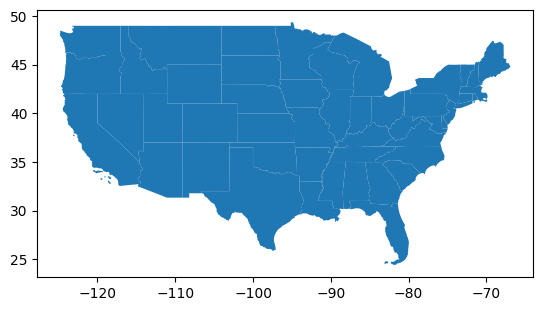

In [9]:
#limit the map to the contiguous US
state = state.cx[-125:-66, 25:50]
state.plot()

In [11]:
state = state[['GEOID', 'state_name', 'ppl_density', 'geometry']]

In [12]:
state

,GEOID,state_name,ppl_density,geometry
0,54,West Virginia,74.578890,"POLYGON ((-77.75438 39.33346, -77.75422 39.333..."
1,12,Florida,403.224200,"MULTIPOLYGON (((-83.10874 24.62949, -83.10711 ..."
2,17,Illinois,229.812600,"POLYGON ((-87.89243 38.28285, -87.89334 38.282..."
3,27,Minnesota,71.520520,"POLYGON ((-95.31991 48.99892, -95.31778 48.998..."
4,24,Maryland,634.497900,"POLYGON ((-75.756 39.24607, -75.75578 39.24334..."
5,44,Rhode Island,1058.381000,"MULTIPOLYGON (((-71.67881 41.15891, -71.67626 ..."
6,16,Idaho,22.434580,"POLYGON ((-116.35844 49.00047, -116.34805 49.0..."
7,33,New Hampshire,154.081700,"POLYGON ((-70.83887 43.24449, -70.83886 43.244..."
8,37,North Carolina,215.330200,"POLYGON ((-77.89977 36.5446, -77.89942 36.5446..."
9,50,Vermont,69.849030,"POLYGON ((-72.04187 44.15665, -72.0418 44.1566..."


In [13]:
#export 
state.to_file("../../population_density.geojson", driver='GeoJSON')